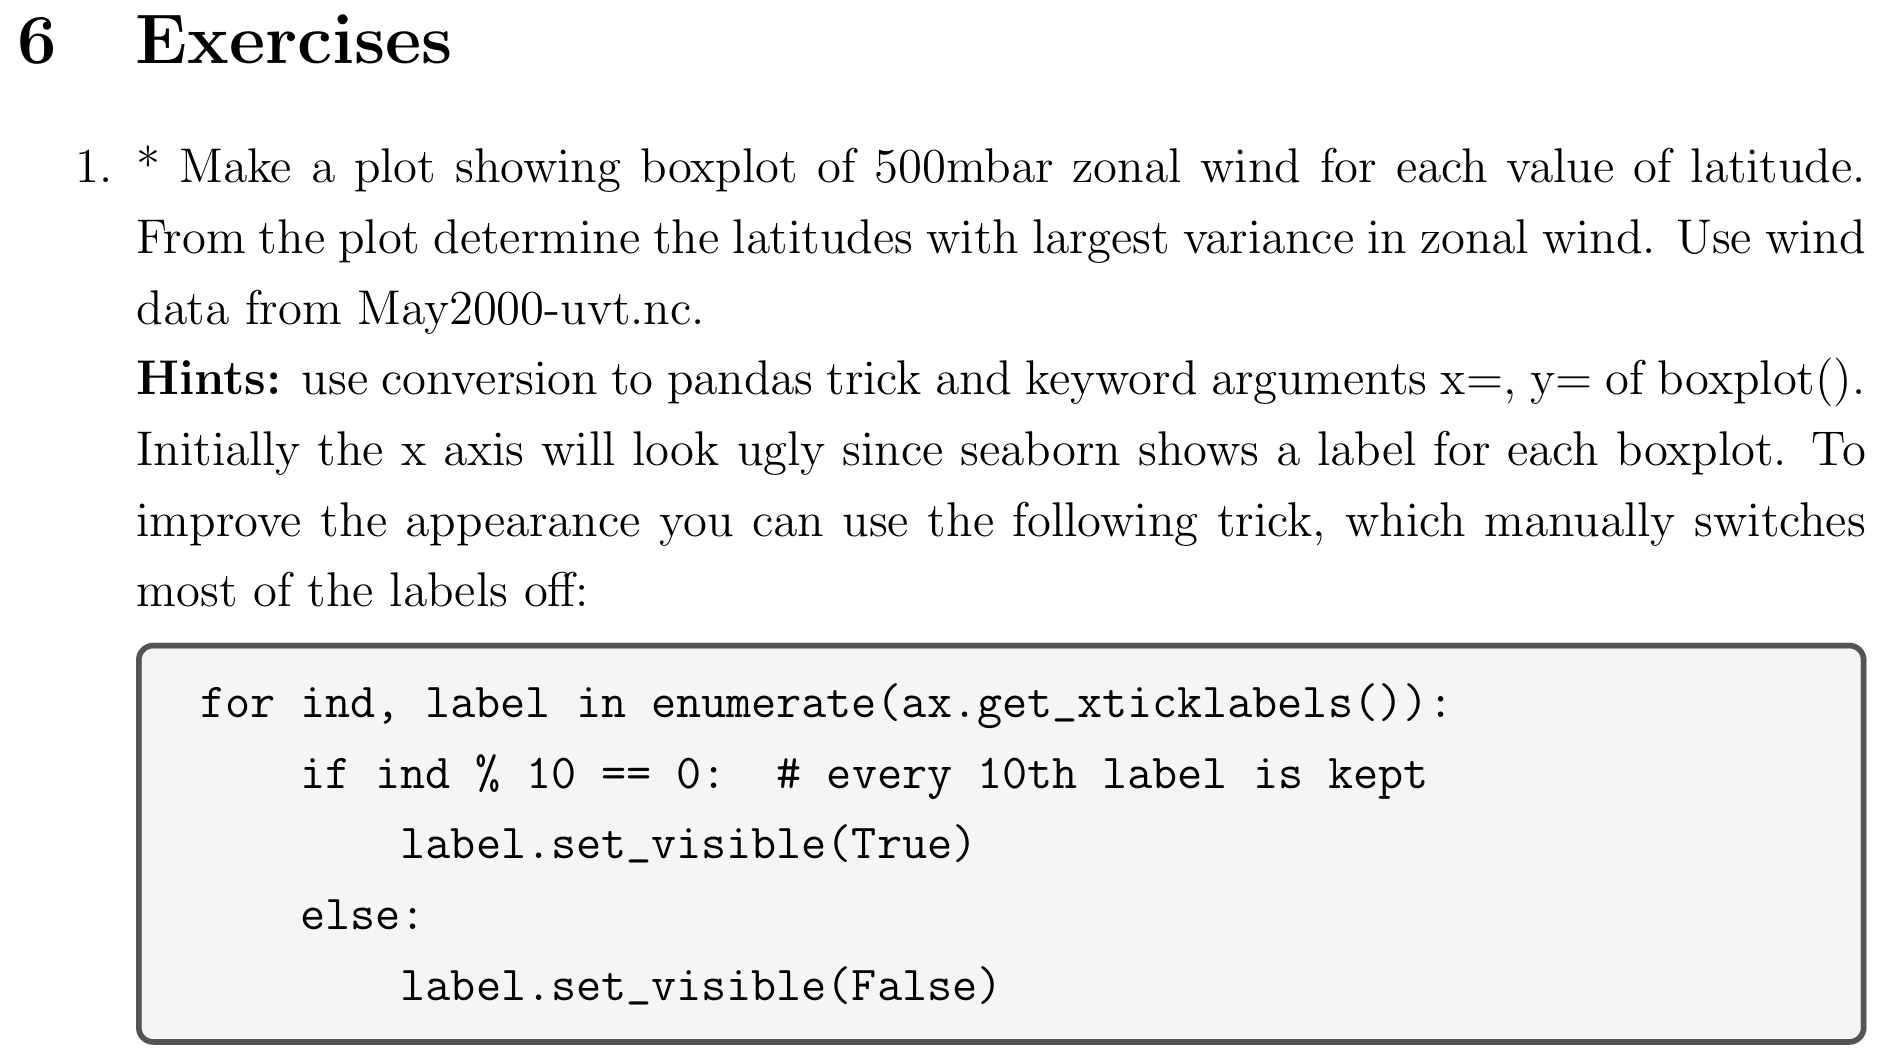

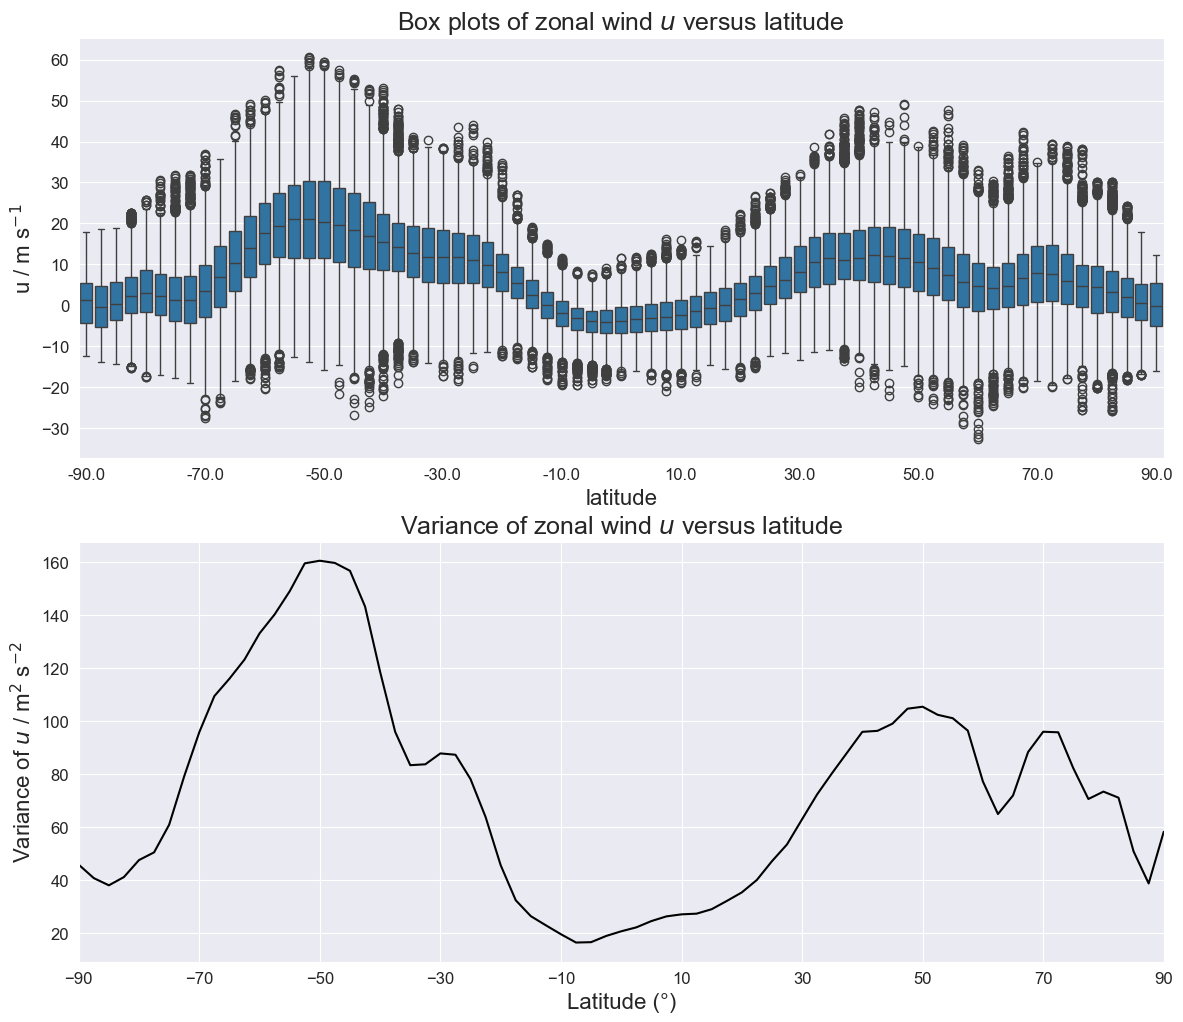

In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from dask.array.overlap import nearest

# Load the data.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')

ds_500 = ds['u'].sel(level=500)

# Convert to DataFrame for box plots on ax1.
df = ds_500.to_dataframe()

# Compute variance for line plot on ax2.
u_var = ds_500.var(dim=['longitude', 'time'])


# Plotting
fig, (ax1, ax2) = plt.subplots(2, figsize=(14, 12))

# Box plots on ax1.
sns.boxplot(data=df, x='latitude', y='u', ax=ax1)

for idx, label in enumerate(ax1.get_xticklabels()):
    label.set_visible(idx % 8 == 0)

ax1.set_yticks(np.arange(-30, 65, 10))

ax1.set_ylabel(r'u / m s$^{-1}$', fontsize=16)
ax1.xaxis.label.set_size(16)
ax1.set_title(r'Box plots of zonal wind $u$ versus latitude', fontsize=18)
ax1.tick_params(axis='both', which='major', labelsize=12)


# Variance plot on ax2.
u_var.plot(ax=ax2, color='k')

ax2.set_ylabel(r'Variance of $u$ / m$^2$ s$^{-2}$', fontsize=16)
ax2.set_xlabel('Latitude (°)', fontsize=16)
ax2.set_title(r'Variance of zonal wind $u$ versus latitude', fontsize=18)

ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_xticks(np.arange(-90, 91, 20))
ax2.set_xlim(-90, 90)


plt.show()

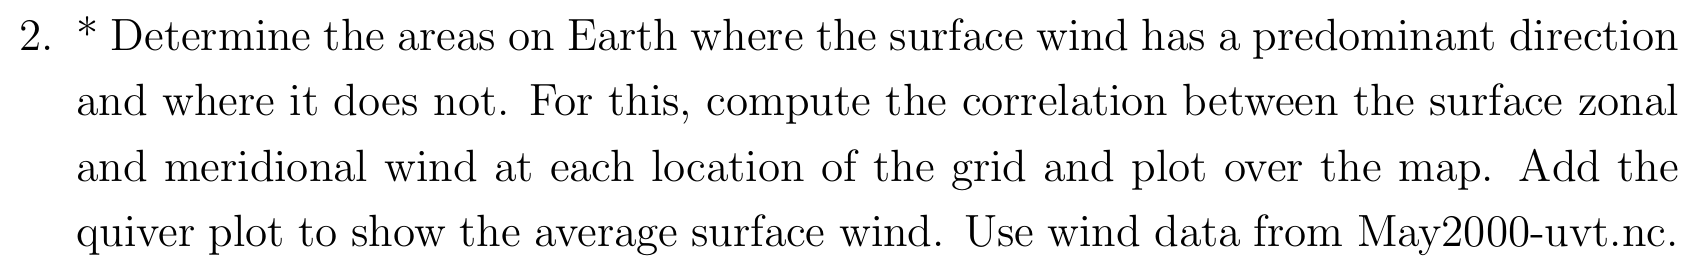

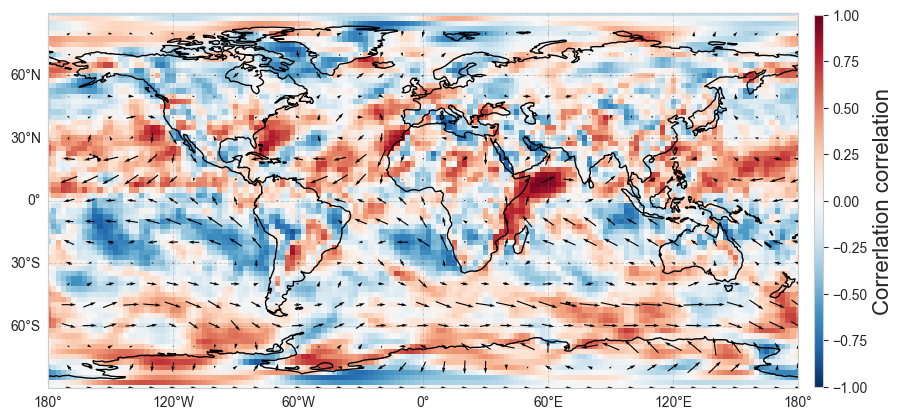

In [86]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


# Load the data.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')

u = ds['u'].sel(level=1000)
v = ds['v'].sel(level=1000)

corr = xr.corr(u, v, dim=['time'])
# try with np as well

lons, lats = np.meshgrid(u.longitude, u.latitude)
u_mean = u.mean(dim='time')
v_mean = v.mean(dim='time')


# Plotting.
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

ax.coastlines()

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)
gl.top_labels = False
gl.right_labels = False

corr_plot = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    corr,
    transform=ccrs.PlateCarree(),
    vmin=-1,
    vmax=1,
    cmap='RdBu_r'
)

skip = 4

wind_plot = ax.quiver(
    lons[::skip, ::skip],
    lats[::skip, ::skip],
    u_mean[::skip, ::skip],
    v_mean[::skip, ::skip],
    transform=ccrs.PlateCarree(),

    scale=400,
    width=0.0015,
    pivot='middle'
)

cbar = fig.colorbar(
    corr_plot,
    ax=ax,
    pad=0.02,
    aspect=40,
    fraction=0.012
)
cbar.set_label(r'Correrlation correlation', fontsize=16)

plt.show()


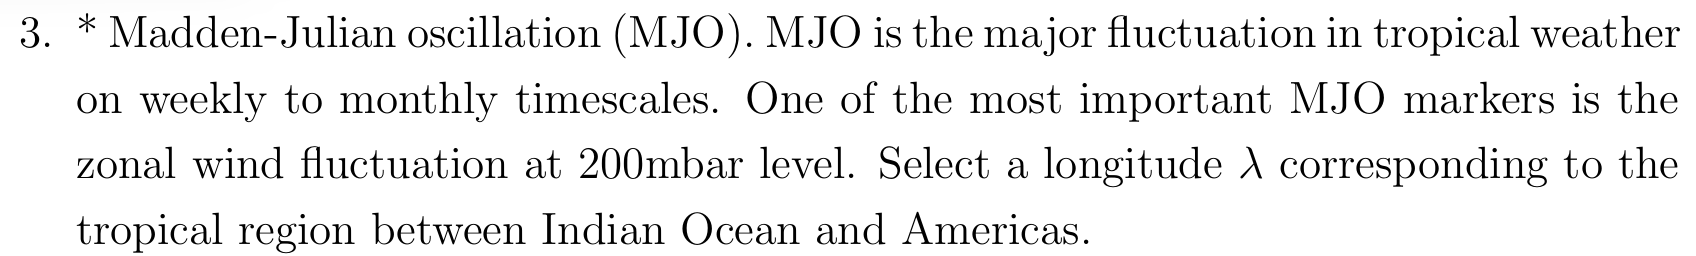
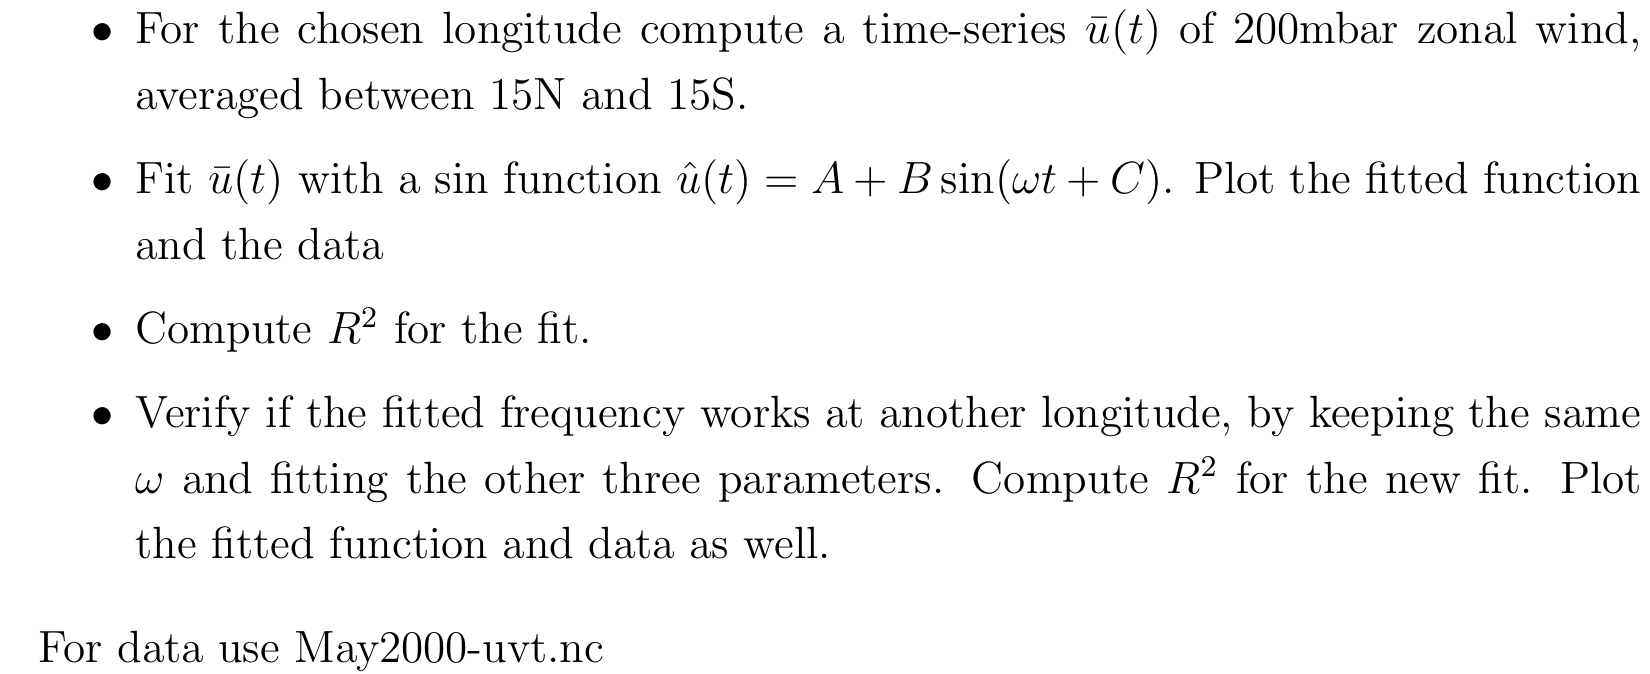

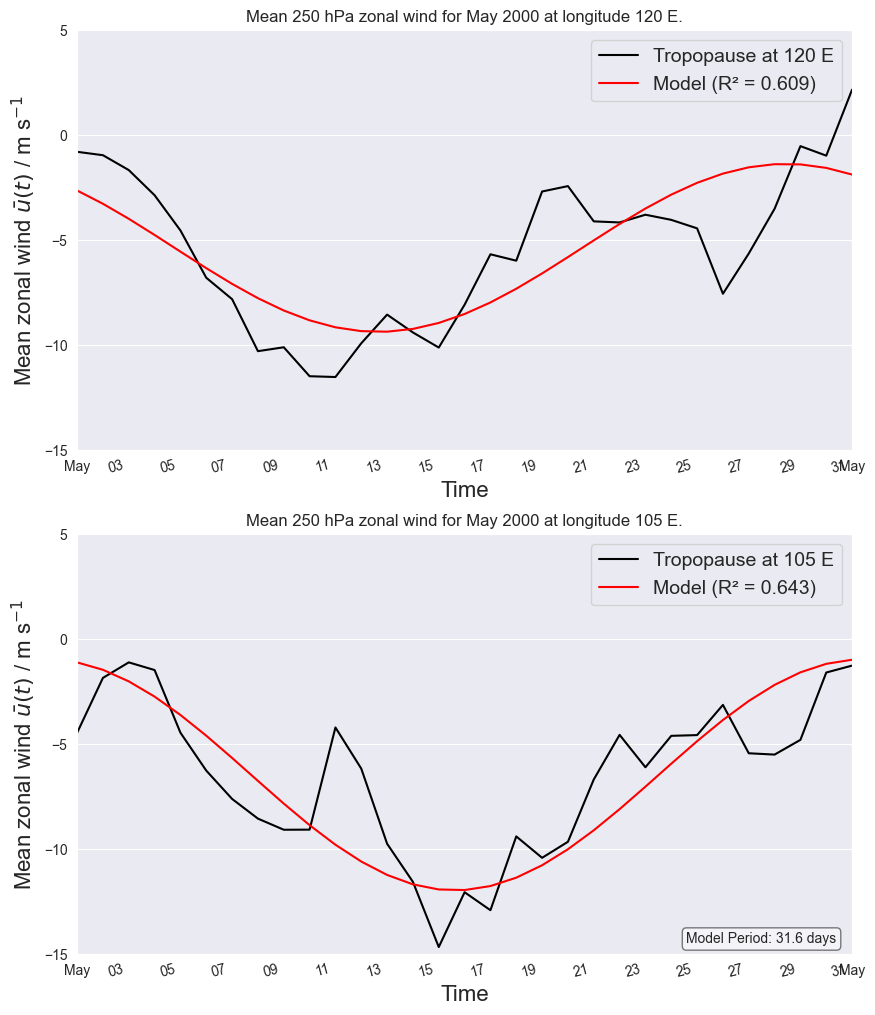

In [62]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import xarray as xr


# Load the data.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')


# Select u wind at 250 hPa at a longitude and average it over latitudes 15N and 15S.
lon_1 = 120
u_trop_1 = ds['u'].sel(longitude=lon_1, latitude=slice(15, -15), level=250).mean(dim='latitude')

lon_2 = 105
u_trop_2 = ds['u'].sel(longitude=lon_2, latitude=slice(15, -15), level=250).mean(dim='latitude')

t = u_trop_1.time.values.astype("datetime64[s]").astype(float)
t = (t - t[0]) / 86_400


# Define sine model for curve-fitting with first guess.
def sine_model(t, a, b, w, c):
    return a + b * np.sin(w * t + c)

# guess = [
#     u_trop.mean(dim='time'),
#     0.5 * (u_trop.max(dim='time') - u_trop.min(dim='time')),
#     2*np.pi / 15,
#     0
# ]

guess = [
    -7.5,
    10,
    2*np.pi / 20,
    2
]

coefs_1, _ = curve_fit(
    sine_model,
    t,
    u_trop_1.values,
    p0=guess,
    bounds=((-10, 4, -1, -30),
            (0, 20, 1, 30))
)
a, b, w, c = coefs_1

u_trop_1_pred = sine_model(t, a, b, w, c)


# Define sine model with same frequency for another latitude.
u_trop_2_pred = sine_model(t, -6.45, 5.5, w, 1.8)


# Compute the model period
model_period = 2*np.pi / w


# Compute R² for both cases
r2 = r2_score(u_trop_1, u_trop_1_pred)
r2_2 = r2_score(u_trop_2, u_trop_2_pred)


# Plotting.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

ax1.plot(u_trop_1.time, u_trop_1, color='black', label=f'Tropopause at {lon_1} E')

ax1.plot(u_trop_1.time, u_trop_1_pred, color='red', label=f"Model (R² = {r2:.3f})")

ax1.set_xlabel("Time", fontsize=16)
ax1.set_ylabel(r"Mean zonal wind $\bar{u}(t)$ / m s$^{-1}$", fontsize=16)
ax1.set_title(f"Mean 250 hPa zonal wind for May 2000 at longitude {lon_1} E.")

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.xaxis.set_minor_locator(mdates.DayLocator(interval=2))
ax1.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

ax1.tick_params(axis='x', which='minor', rotation=15)
ax1.set_yticks(np.arange(-15, 6, 5))

ax1.set_xlim(u_trop.time.min(), u_trop.time.max())
ax1.set_ylim(-15, 5)

ax.text(
    x=0.90,
    y=0.02,
    s=f"Model Period: {model_period} days.",
    transform=ax.transAxes,
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.5)
)

ax1.legend(fontsize=14)


ax2.plot(u_trop_2.time, u_trop_2, color='black', label=f'Tropopause at {lon_2} E')

ax2.plot(u_trop_2.time, u_trop_2_pred, color='red', label=f"Model (R² = {r2_2:.3f})")

ax2.set_xlabel("Time", fontsize=16)
ax2.set_ylabel(r"Mean zonal wind $\bar{u}(t)$ / m s$^{-1}$", fontsize=16)
ax2.set_title(f"Mean 250 hPa zonal wind for May 2000 at longitude {lon_2} E.")

ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.xaxis.set_minor_locator(mdates.DayLocator(interval=2))
ax2.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

ax2.tick_params(axis='x', which='minor', rotation=15)
ax2.set_yticks(np.arange(-15, 6, 5))

ax2.set_xlim(u_trop.time.min(), u_trop.time.max())
ax2.set_ylim(-15, 5)

ax2.text(
    0.98, 0.02,
    f"Model Period: {model_period:.1f} days",
    transform=ax2.transAxes,
    ha='right',
    va='bottom',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.5
    )
)

ax2.legend(fontsize=14)


plt.show()

In [18]:
coefs

array([-5.35548283,  4.        ,  0.19912929,  2.38984481])

In [57]:
w

np.float64(0.19912929348618946)

In [59]:
model_period

np.float64(2726204.673537731)

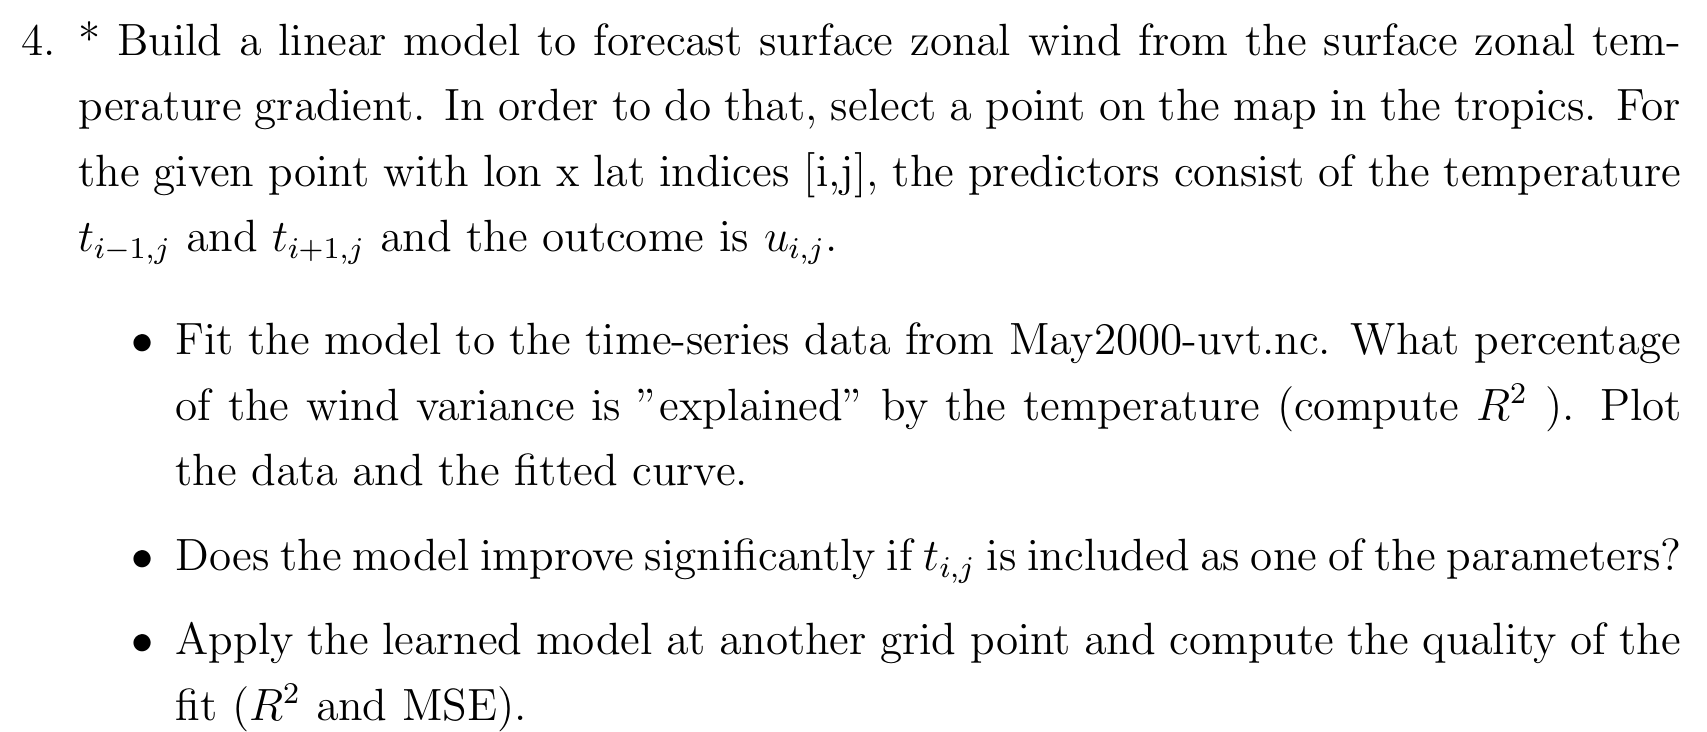

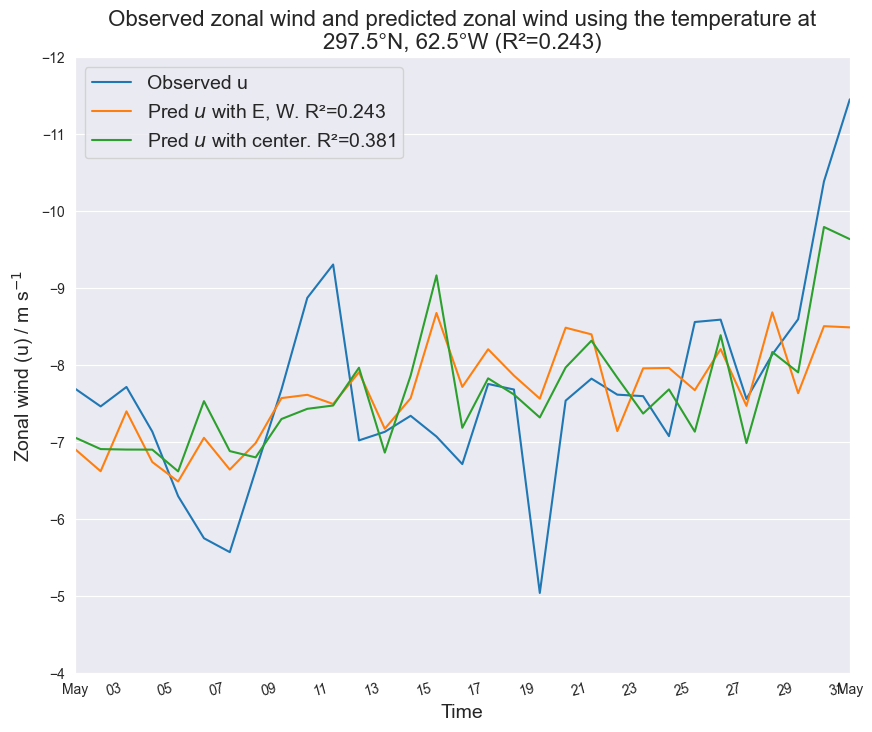

In [42]:
from pathlib import Path
import textwrap

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import r2_score
import xarray as xr


# Load the data.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')


# Select point on map
lon, lat = 298.3, 12.3
level = 1000

# Load observed u.
u_obs = ds['u'].sel(longitude=lon, latitude=lat, level=level, method='nearest')

# Get index of the longitude.
i = ds.get_index("longitude").get_loc(float(u_obs.longitude))

# Select temperature west and east of longitude i.
T_west = ds['t'].isel(longitude=(i-1)).sel(latitude=lat, level=level, method='nearest')
T_east = ds['t'].isel(longitude=(i+1)).sel(latitude=lat, level=level, method='nearest')

# Create matrix for predictors T_west and T_east
T_pred = np.column_stack((T_west, T_east))

# Fit regression model.
regr1 = linear_model.LinearRegression()
regr1.fit(T_pred, u_obs)
u_pred = regr1.predict(T_pred)

# Compute R² using the T_west and T_east.
r2 = r2_score(u_obs, u_pred)


# Select temperature at longitude i.
T_i = ds['t'].isel(longitude=i).sel(latitude=lat, level=level, method='nearest')

# Create matrix for predictors T_west, T_i, and T_east.
T_pred2 = np.column_stack((T_west, T_i, T_east))

# Fit regression model.
regr2 = linear_model.LinearRegression()
regr2.fit(T_pred2, u_obs)
u_pred2 = regr2.predict(T_pred2)

r2_2 = r2_score(u_obs, u_pred2)

# Plotting.
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(u_obs.time, u_obs, label=r"Observed u")
ax.plot(u_obs.time, u_pred, label=rf"Pred $u$ with E, W. R²={r2:.3f}")
ax.plot(u_obs.time, u_pred2, label=rf"Pred $u$ with center. R²={r2_2:.3f}")

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel(r"Zonal wind (u) / m s$^{-1}$", fontsize=14)
ax.set_title(textwrap.fill(f"Observed zonal wind and predicted zonal wind using the temperature at {float(u_obs.longitude)}°N, {(float(u_obs.longitude) - 235):.1f}°W (R²={r2:.3f})", max_lines=2), fontsize=16)

ax.set_ylim(-12, -4)
ax.invert_yaxis()
ax.set_xlim(u_obs.time.min(), u_obs.time.max())

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

ax.tick_params(axis='x', which='minor', rotation=15)

ax.legend(fontsize=14)

plt.show()

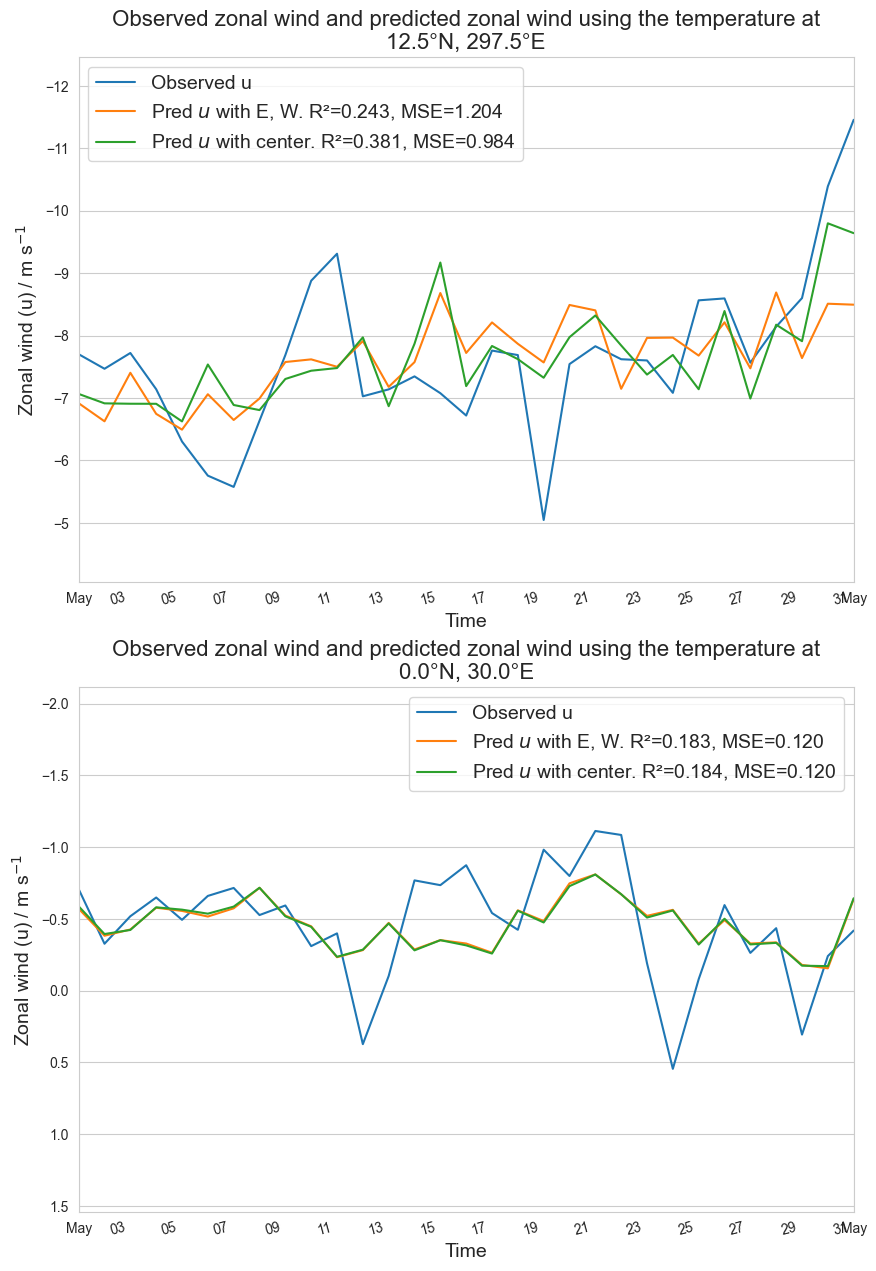

In [12]:
from pathlib import Path
import textwrap

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_squared_error
import xarray as xr


def select_predictors_and_observations(ds, lon, lat, level):
    """Select the surface temperature predictors and wind observations for a given coordinate."""
    # Load observed u.
    u_obs = ds['u'].sel(longitude=lon, latitude=lat, level=level, method='nearest')

    # Get index of the longitude.
    i = ds.get_index("longitude").get_loc(float(u_obs.longitude))

    # Select temperature west and east of longitude i.
    T_west = ds['t'].isel(longitude=(i-1)).sel(latitude=lat, level=level, method='nearest')
    T_east = ds['t'].isel(longitude=(i+1)).sel(latitude=lat, level=level, method='nearest')
    T_i = ds['t'].isel(longitude=i).sel(latitude=lat, level=level, method='nearest')

    return T_east, T_i, T_west, u_obs


def u_pred(u_obs, *predictors):
    """Predict zonal wind using temperature predictors."""
    # Create matrix for predictors T_west and T_east
    X = np.column_stack(predictors)

    # Fit regression model.
    regr = linear_model.LinearRegression()
    regr.fit(X, u_obs)
    u_pred = regr.predict(X)

    # Compute R² using the T_west and T_east.
    r2 = r2_score(u_obs, u_pred)

    # Compute MSE.
    mse = mean_squared_error(u_obs, u_pred)

    return u_pred, r2, mse


# Load the dataset.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')


# Select points on map.
lon1, lat1 = 298.3, 12.3
level = 1000

lon2, lat2 = 30, 0

times = ds.time.values


# Load the data for each coordinate.
T_east_1, T_i_1, T_west_1, u_obs_1 = select_predictors_and_observations(ds, lon1, lat1, level)
T_east_2, T_i_2, T_west_2, u_obs_2 = select_predictors_and_observations(ds, lon2, lat2, level)


# Compute predicted zonal wind and R².
u_pred_a1, r2_a1, mse_a1 = u_pred(u_obs_1, T_east_1, T_west_1)
u_pred_a2, r2_a2, mse_a2 = u_pred(u_obs_1, T_east_1, T_i_1, T_west_1)

u_pred_b1, r2_b1, mse_b1 = u_pred(u_obs_2, T_east_2, T_west_2)
u_pred_b2, r2_b2, mse_b2 = u_pred(u_obs_2, T_east_2, T_i_1, T_west_2)


# Create dictionary for the data.
data = {
    "point A": {
        'u_obs': u_obs_1,
        'u_pred': u_pred_a1,
        'u_pred2': u_pred_a2,
        'r2': float(r2_a1),
        'r2_2': float(r2_a2),
        'mse': float(mse_a1),
        'mse2': float(mse_a2)
    },
    "point B": {
        'u_obs': u_obs_2,
        'u_pred': u_pred_b1,
        'u_pred2': u_pred_b2,
        'r2': r2_b1,
        'r2_2': r2_b2,
        'mse': float(mse_b1),
        'mse2': float(mse_b2)
    }
}


# Plotting.
fig, axes = plt.subplots(2, 1, figsize=(10, 15))

for idx, (_, point) in enumerate(data.items()):
    u_obs  = point['u_obs']
    u_pred = point['u_pred']
    u_pred2 = point['u_pred2']
    r2 = point['r2']
    r2_2 = point['r2_2']
    mse = point['mse']
    mse2 = point['mse2']

    ax = axes[idx]

    ax.plot(times, u_obs, label=r"Observed u")
    ax.plot(times, u_pred, label=rf"Pred $u$ with E, W. R²={r2:.3f}, MSE={mse:.3f}")
    ax.plot(times, u_pred2, label=rf"Pred $u$ with center. R²={r2_2:.3f}, MSE={mse2:.3f}")

    ax.set_xlabel("Time", fontsize=14)
    ax.set_ylabel(r"Zonal wind (u) / m s$^{-1}$", fontsize=14)
    ax.set_title(textwrap.fill(f"Observed zonal wind and predicted zonal wind using the temperature at {float(u_obs.latitude)}°N, {(float(u_obs.longitude)):.1f}°E", max_lines=2), fontsize=16)

    ax.set_ylim(u_obs.min() - 1, u_obs.max() + 1)
    ax.invert_yaxis()
    ax.set_xlim(u_obs.time.min(), u_obs.time.max())

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))

    ax.tick_params(axis='x', which='minor', rotation=15)

    ax.legend(fontsize=14)

plt.show()

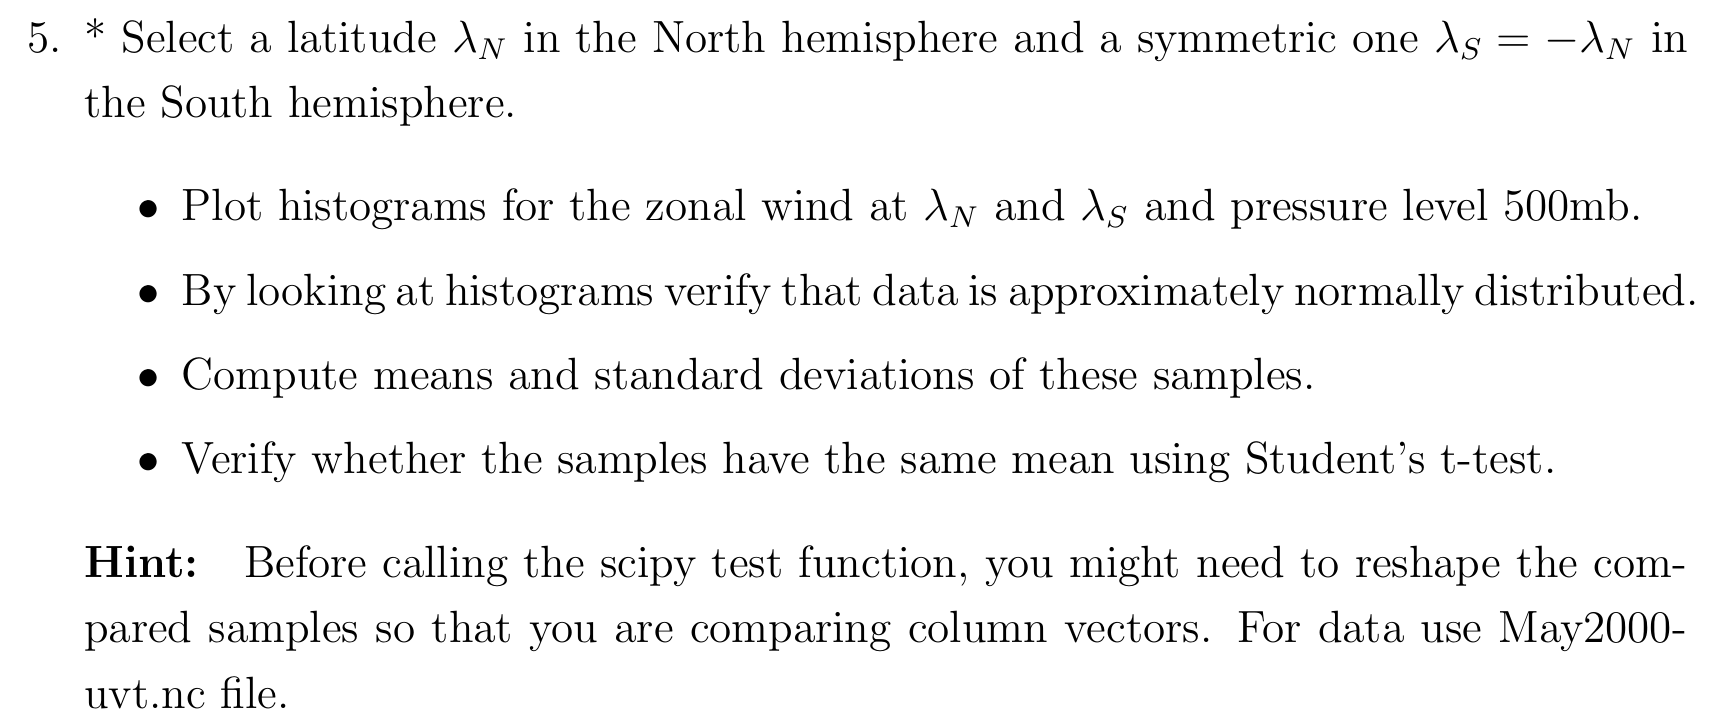

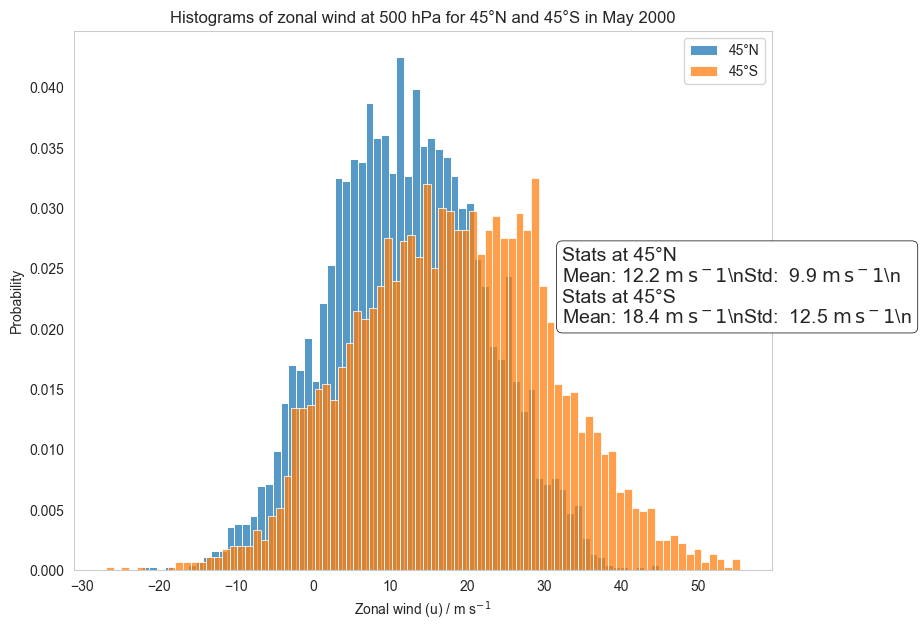

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr


# Load the data.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')


# Select
lat_n = 45
lat_s = - lat_n
level = 500

u_500_n = ds['u'].sel(latitude=lat_n, level=level, method='nearest').values.ravel()
u_500_n_mean = u_500_n.mean()
u_500_n_std = u_500_n.std()

u_500_s = ds['u'].sel(latitude=lat_s, level=level, method='nearest').values.ravel()
u_500_s_mean = u_500_s.mean()
u_500_s_std = u_500_s.std()

# Plotting
fig, ax = plt.subplots(figsize=(9, 7))

sns.histplot(
    data=u_500_n,
    stat='probability',
    binwidth=1,
    label="45°N",
    ax=ax
)

sns.histplot(
    data=u_500_s,
    stat='probability',
    binwidth=1,
    label="45°S",
    ax=ax
)

text = (
    "Stats at 45°N\n"
    rf"Mean: {u_500_n_mean:.1f} $\mathrm{{m\,s^{-1}}}$\n"
    rf"Std:  {u_500_n_std:.1f} $\mathrm{{m\,s^{-1}}}$\n"
    "\n"   # <-- this creates a real blank line
    "Stats at 45°S\n"
    rf"Mean: {u_500_s_mean:.1f} $\mathrm{{m\,s^{-1}}}$\n"
    rf"Std:  {u_500_s_std:.1f} $\mathrm{{m\,s^{-1}}}$\n"
)

ax.text(
    x=0.70,
    y=0.60,
    s=text,
    transform=ax.transAxes,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', fc='w', ec='k', lw=0.5),
    fontsize=14,
)

ax.set_xlabel(r"Zonal wind (u) / m s$^{-1}$")
ax.set_ylabel("Probability")
ax.set_title(f"Histograms of zonal wind at {level} hPa for 45°N and 45°S in May 2000")

ax.set_xticks(np.arange(-30, 56, 10))

ax.legend()
ax.grid(False)

plt.show()


In [21]:
u_500_n_mean

np.float64(12.167711509332763)

In [2]:
ds

<xarray.Dataset> Size: 55MB
Dimensions:    (longitude: 144, latitude: 73, level: 7, time: 31)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * level      (level) int32 28B 1 10 100 250 500 775 1000
  * time       (time) datetime64[ns] 248B 2000-05-01T12:00:00 ... 2000-05-31T...
Data variables:
    t          (time, level, latitude, longitude) float64 18MB ...
    u          (time, level, latitude, longitude) float64 18MB ...
    v          (time, level, latitude, longitude) float64 18MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 22:12:40 GMT by grib_to_netcdf-2.21.0: grib_to_n...

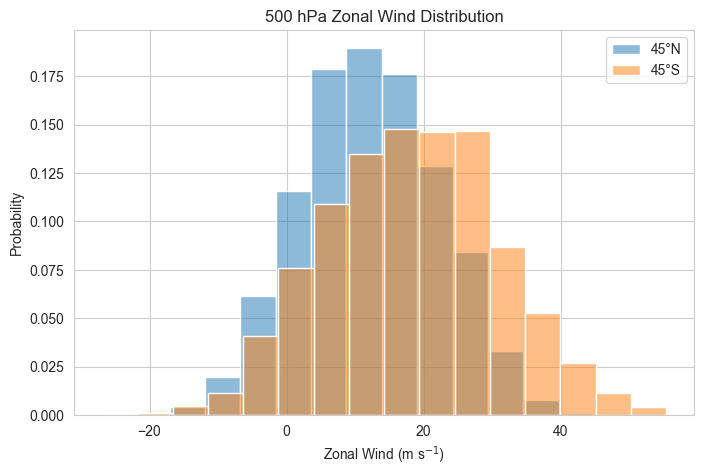

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

# Load the data.
path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')

# Select
lat_n = 45
lat_s = -lat_n
level = 500

u_500_n = ds['u'].sel(latitude=lat_n, level=level, method='nearest')
u_500_s = ds['u'].sel(latitude=lat_s, level=level, method='nearest')

# Convert to 1D arrays
u_500_n = u_500_n.values.ravel()
u_500_s = u_500_s.values.ravel()

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    u_500_n,
    stat='probability',
    binwidth=5,
    alpha=0.5,
    label=f'{lat_n}°N',
    ax=ax
)

sns.histplot(
    u_500_s,
    stat='probability',
    binwidth=5,
    alpha=0.5,
    label=f'{abs(lat_s)}°S',
    ax=ax
)

ax.set_xlabel('Zonal Wind (m s$^{-1}$)')
ax.set_ylabel('Probability')
ax.set_title(f'500 hPa Zonal Wind Distribution')
ax.legend()

plt.show()